## Operationalizations of multi-level polarization measure afforded by ResIN

In [1]:
import pandas as pd
import numpy as np
from typing import List, Dict, Any

from src.build_network import ResIN
import networkx as nx

import matplotlib.pyplot as plt
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats("retina")
from adjustText import adjust_text

import yaml
with open("../../src/configs.yml", "r") as configs:
    configs = yaml.safe_load(configs)

ROOTPATH = configs["ROOTPATH"]
ROOTPATH2 = configs["ROOTPATH2"]
# OUTPATH = "../../output/results-summary-091624/"
OUTPATH = "../../output/results-summary-092724/"

print(configs)

{'ROOTPATH': '/Users/yijingch/Documents/GITHUB/broken-egg-polarization/', 'GITHUBPATH': '/Users/yijingch/Documents/GITHUB/', 'ROOTPATH2': '/Users/yijingch/Dropbox/CSS 2023 Attitude Networks/ANES/Cumulative'}


In [2]:
anes_all = pd.read_csv(ROOTPATH + "data/anes_out_090624.csv").drop(columns=["Unnamed: 0"])
YEARS = [2000, 2004, 2008, 2012, 2016, 2020]
anes_all = anes_all[anes_all["year"].isin(YEARS)]
anes_all["ft_rep_net"] = anes_all["ft_rep"] - anes_all["ft_dem"] # compute the net value of ft rep/dem
anes_all["ft_rep_net_abs"] = anes_all["ft_rep_net"].map(lambda x: abs(x))

# # adjust reverse scale so that the direction of answers are aligned
# anes_all["spend_serv"] = anes_all["spend_serv"].map(lambda x: 8-x)
# anes_all["abort"] = anes_all["abort"].map(lambda x: 5-x)

PARTISAN_LABEL_CATG = {
    1: -1, 2: -1, 3: -1, 
    4: 0,
    5: 1, 6: 1, 7: 1,
}

anes_all["dem_rep_3"] = anes_all["dem_rep"].map(lambda x: PARTISAN_LABEL_CATG[x] if not np.isnan(x) else np.NaN)
anes_all = anes_all[anes_all["dem_rep_3"].notna()]
print("# of NaN:", len(anes_all[anes_all["dem_rep_3"].isna()]))
print("# of independents:", len(anes_all[anes_all["dem_rep_3"]==0]))
anes_all.head()


# of NaN: 0
# of independents: 2948


,year,gov_health,guar_jobs,us_isolate,aid_black,abort,spend_serv,def_spend,aff_act_1,aff_act_2,...,hw_asian,it_access,it_campaign,left_right,lbrl_cnsv,dem_rep,weights,ft_rep_net,ft_rep_net_abs,dem_rep_3
11295,2000,5.0,6.0,NaN,NaN,2.0,3.0,6.0,5.0,5.0,...,4.0,1.0,1.0,NaN,NaN,5.0,1.2886,16.0,16.0,1.0
11296,2000,NaN,NaN,2.0,NaN,4.0,NaN,NaN,5.0,5.0,...,1.0,1.0,5.0,NaN,NaN,3.0,0.8959,NaN,NaN,-1.0
11297,2000,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,7.0,...,5.0,1.0,5.0,NaN,NaN,1.0,1.0454,-30.0,30.0,-1.0
11298,2000,NaN,NaN,2.0,NaN,4.0,NaN,NaN,5.0,5.0,...,1.0,5.0,5.0,NaN,5.0,3.0,0.6005,-5.0,5.0,-1.0
11299,2000,NaN,NaN,NaN,NaN,3.0,NaN,NaN,5.0,5.0,...,1.0,5.0,5.0,NaN,6.0,7.0,1.9270,70.0,70.0,1.0


In [3]:
anes_all.columns

Index(['year', 'gov_health', 'guar_jobs', 'us_isolate', 'aid_black', 'abort',
       'spend_serv', 'def_spend', 'aff_act_1', 'aff_act_2', 'gay_discr',
       'immigrat', 'spend_poor', 'spend_child', 'spend_crime', 'spend_school',
       'spend_welfare', 'spend_env', 'spend_socsec', 'black_fairjob',
       'import_lim', 'death_pen', 'gun_own', 'def_spend_D', 'aid_black_D',
       'gov_health_D', 'spend_serv_D', 'guar_jobs_D', 'lib_con_D', 'abort_D',
       'def_spend_R', 'aid_black_R', 'gov_health_R', 'spend_serv_R',
       'guar_jobs_R', 'lib_con_R', 'abort_R', 'lib_con', 'pid', 'egal_1',
       'egal_2', 'auth_1', 'auth_2', 'auth_3', 'auth_4', 'rac_res_1',
       'rac_res_2', 'rac_res_3', 'rac_res_4', 'penalty_favopp', 'ft_jews',
       'ft_blacks', 'ft_whites', 'ft_bis', 'ft_lab', 'ft_lib', 'ft_con',
       'ft_his', 'ft_dem', 'ft_poor', 'ft_rep', 'ft_asian', 'ft_congr',
       'ft_gay', 'ft_immigr', 'ft_chrfund', 'ft_fem', 'ft_mus', 'ft_chr',
       'hw_whites', 'hw_blacks', 'hw_his

In [4]:
PARTISAN_LABEL_CATG = {
    1: -1, 2: -1, 3: -1, 
    4: 0,
    5: 1, 6: 1, 7: 1,
}

# anes_all["dem_rep_3"] = anes_all["dem_rep"].map(lambda x: PARTISAN_LABEL_CATG[x] if not np.isnan(x) else np.NaN)
# anes_all = anes_all[anes_all["dem_rep_3"].notna()]

In [5]:
NODE_COLS = [
    "spend_serv", "gov_health", "guar_jobs", "abort", "aid_black",
    # "immigrat", "gun_own", "spend_school", "spend_crime", "spend_welfare",
    # "spend_poor", "penalty_favopp", "gay_discr", "aff_act_2", 
    # "left_right", "lbrl_cnsv"
]

# COV_COLS = ["ft_rep_net"]
COV_COLS = ["dem_rep_3"]

In [6]:
# RESIN_DICT = {}
# NEUTRAL_VAL_DICT = {}
# for year in YEARS:
#     print("processing:", year)
#     anes_year = anes_all[anes_all["year"]==year].copy()
#     anes_year = anes_year[NODE_COLS + COV_COLS]
#     resin = ResIN(df=anes_year, node_cols=NODE_COLS)
#     resin.make_graph(square_corr=False, remove_nan=True)
#     resin.compute_covariates(covariate_cols=COV_COLS)
#     resin.adjust_coordinates()
#     resin.get_item_size()
#     resin.set_edge_distance()
#     RESIN_DICT[year] = resin
#     # NEUTRAL_VAL_DICT[year] = np.nanmean(anes_year["ft_rep_net"])

## Network level 

In [7]:
from src.polar_measures import get_modularity, get_diameter, get_pol_distance
from src.polar_measures import get_linearization, get_binary_comm, get_assortativity
from src.polar_measures import get_density_weighted

In [8]:
mod_ls_bstr = {}
dia_ls_bstr = {}
lin_ls_bstr = {}
dst_ls_bstr = {}
ast_ls_bstr = {}
des_ls_bstr = {}
dem_des_ls_bstr = {}
rep_des_ls_bstr = {}

comm_attr = "dem_rep_3"
nruns = 200

for year in YEARS:
    mod_ls_bstr[year] = []
    dia_ls_bstr[year] = []
    lin_ls_bstr[year] = []
    dst_ls_bstr[year] = []
    ast_ls_bstr[year] = []
    des_ls_bstr[year] = []
    rep_des_ls_bstr[year] = []
    dem_des_ls_bstr[year] = []

    print("processing:", year)
    for r in range(nruns):
        print("- run:", r)
        anes_year_bstr = anes_all[anes_all["year"]==year].sample(frac=.8, replace=False).copy()
        anes_year_bstr = anes_year_bstr[NODE_COLS + COV_COLS]
        resin = ResIN(df=anes_year_bstr, node_cols=NODE_COLS)
        resin.make_graph(square_corr=False, remove_nan=True)
        resin.compute_covariates(covariate_cols=COV_COLS)
        resin.adjust_coordinates()
        resin.set_edge_distance()

        comms = get_binary_comm(resin, comm_attr)
        rep_subg = nx.subgraph(resin.g, comms[0])
        dem_subg = nx.subgraph(resin.g, comms[1])

        mod = get_modularity(resin, comms)
        dia = get_diameter(resin, weight_col="distance")
        lin = get_linearization(resin)
        dst = get_pol_distance(resin)
        ast = get_assortativity(resin, node_attr=comm_attr)

        des = get_density_weighted(resin.g, weight_col="weight")
        rep_des = get_density_weighted(rep_subg, weight_col="weight")
        dem_des = get_density_weighted(dem_subg, weight_col="weight")   

        mod_ls_bstr[year].append(mod)
        dia_ls_bstr[year].append(dia)
        lin_ls_bstr[year].append(lin)
        dst_ls_bstr[year].append(dst)
        ast_ls_bstr[year].append(ast)
        des_ls_bstr[year].append(des)
        rep_des_ls_bstr[year].append(rep_des)
        dem_des_ls_bstr[year].append(dem_des)

# for five items it's going to take ~ 5m31s

processing: 2000
- run: 0
- run: 1
- run: 2
- run: 3
- run: 4
- run: 5
- run: 6
- run: 7
- run: 8
- run: 9
- run: 10
- run: 11
- run: 12
- run: 13
- run: 14
- run: 15
- run: 16
- run: 17
- run: 18
- run: 19
- run: 20
- run: 21
- run: 22
- run: 23
- run: 24
- run: 25
- run: 26
- run: 27
- run: 28
- run: 29
- run: 30
- run: 31
- run: 32
- run: 33
- run: 34
- run: 35
- run: 36
- run: 37
- run: 38
- run: 39
- run: 40
- run: 41
- run: 42
- run: 43
- run: 44
- run: 45
- run: 46
- run: 47
- run: 48
- run: 49
- run: 50
- run: 51
- run: 52
- run: 53
- run: 54
- run: 55
- run: 56
- run: 57
- run: 58
- run: 59
- run: 60
- run: 61
- run: 62
- run: 63
- run: 64
- run: 65
- run: 66
- run: 67
- run: 68
- run: 69
- run: 70
- run: 71
- run: 72
- run: 73
- run: 74
- run: 75
- run: 76
- run: 77
- run: 78
- run: 79
- run: 80
- run: 81
- run: 82
- run: 83
- run: 84
- run: 85
- run: 86
- run: 87
- run: 88
- run: 89
- run: 90
- run: 91
- run: 92
- run: 93
- run: 94
- run: 95
- run: 96
- run: 97
- run: 98
- r

In [27]:
# temp
for year in YEARS:
    print(year)
    anes_year_bstr = anes_all[anes_all["year"]==year].sample(frac=.8, replace=False).copy()
    anes_year_bstr = anes_year_bstr[NODE_COLS + COV_COLS]
    resin = ResIN(df=anes_year_bstr, node_cols=NODE_COLS)
    resin.make_graph(square_corr=False, remove_nan=True)
    resin.compute_covariates(covariate_cols=COV_COLS)
    resin.adjust_coordinates()
    resin.set_edge_distance()

    comms = get_binary_comm(resin, comm_attr)
    rep_subg = nx.subgraph(resin.g, comms[0])
    dem_subg = nx.subgraph(resin.g, comms[1])

    mod = get_modularity(resin, comms)
    dia = get_diameter(resin, weight_col="distance")
    lin = get_linearization(resin)
    dst = get_pol_distance(resin)
    ast = get_assortativity(resin, node_attr=comm_attr)

    des = get_density_weighted(resin.g, weight_col="weight")
    rep_des = get_density_weighted(rep_subg, weight_col="weight")
    dem_des = get_density_weighted(dem_subg, weight_col="weight")   
    print("density:", des)
    print("density rep:", rep_des)
    print("density dem:", dem_des)

2000
density: 0.032186890017876627
density rep: 0.07864931848033728
density dem: 0.04200058917975115
2004
density: 0.03500769283106989
density rep: 0.07304644822057833
density dem: 0.05711205647074554
2008
density: 0.035189790485932064
density rep: 0.10708533841032042
density dem: 0.04223644333763675
2012
density: 0.03679611010098063
density rep: 0.10193651169772529
density dem: 0.05272140760916145
2016
density: 0.03922622980150961
density rep: 0.07983549446288542
density dem: 0.07518787103495513
2020
density: 0.04864531054404974
density rep: 0.08590959412577613
density dem: 0.10047803587366856


In [28]:
(0.04864531054404974-0.032186890017876627)/0.032186890017876627

0.5113392600848387

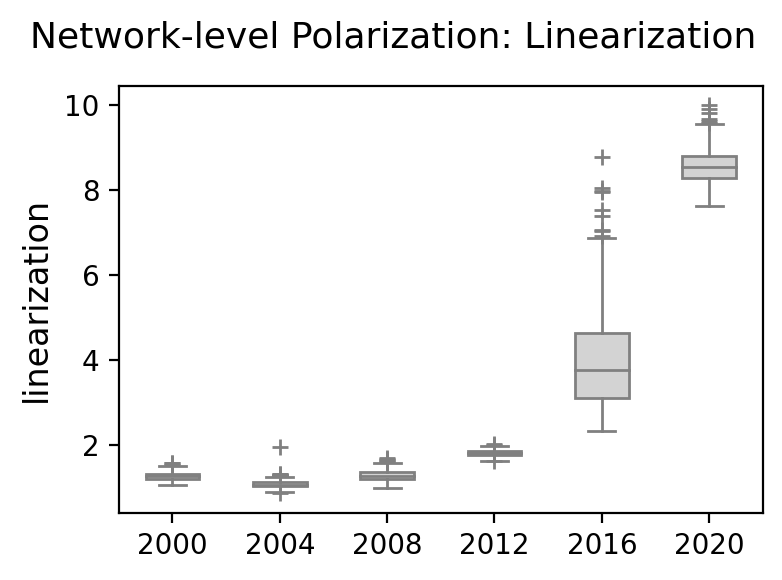

In [24]:
fig,ax = plt.subplots(figsize=(4,3))
bp_lin = ax.boxplot(lin_ls_bstr.values(), sym="+", patch_artist=True)
ax.set_xticks(range(1,7), YEARS)
for item in ["boxes", "whiskers", "fliers", "medians", "caps"]:
        plt.setp(bp_lin[item], color="grey")
        if item =="boxes":
            for patch in bp_lin[item]:
                patch.set_facecolor("lightgrey")
plt.setp(bp_lin["fliers"], markeredgecolor="grey")
ax.set_ylabel("linearization", fontsize=12)
plt.suptitle("Network-level Polarization: Linearization", fontsize=13, y=.95)
plt.tight_layout()
plt.savefig(OUTPATH + "network-level-polar-linearization.pdf", dpi=300, bbox_inches="tight")

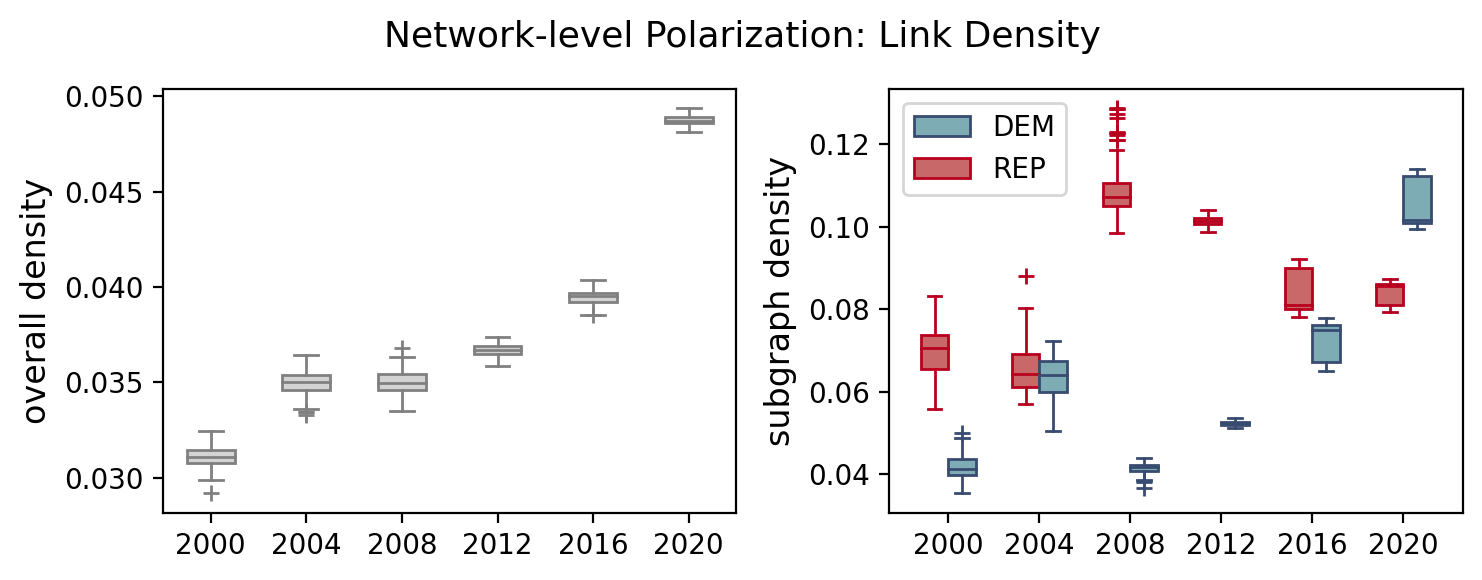

In [15]:
fig,ax = plt.subplots(ncols=2, figsize=(7.5,3))

bp_all = ax[0].boxplot(des_ls_bstr.values(), sym="+", patch_artist=True)
ax[0].set_ylabel("overall density", fontsize=12)

bp_rep = ax[1].boxplot(rep_des_ls_bstr.values(), positions=np.arange(1,7)-.15, sym="+", widths=.3, patch_artist=True)
bp_dem = ax[1].boxplot(dem_des_ls_bstr.values(), positions=np.arange(1,7)+.15, sym="+", widths=.3, patch_artist=True)
ax[1].set_ylabel("subgraph density", fontsize=12)


for item in ["boxes", "whiskers", "fliers", "medians", "caps"]:
        plt.setp(bp_all[item], color="grey")
        plt.setp(bp_dem[item], color="#384B70")
        plt.setp(bp_rep[item], color="#B8001F")
        if item =="boxes":
            for patch in bp_all[item]:
                patch.set_facecolor("lightgrey")
            for patch in bp_rep[item]:
                patch.set_facecolor("#C96868")
            for patch in bp_dem[item]:
                patch.set_facecolor("#7EACB5")

plt.setp(bp_all["fliers"], markeredgecolor="grey")
plt.setp(bp_dem["fliers"], markeredgecolor="#384B70")
plt.setp(bp_rep["fliers"], markeredgecolor="#B8001F")

ax[1].legend([bp_dem["boxes"][1], bp_rep["boxes"][1]], ["DEM", "REP"])

for i in range(2):
    ax[i].set_xticks(range(1,7), YEARS)
plt.suptitle("Network-level Polarization: Link Density", fontsize=13, y=.95)
plt.tight_layout()
plt.savefig(OUTPATH + "network-level-polar-link-density.pdf", dpi=300, bbox_inches="tight")

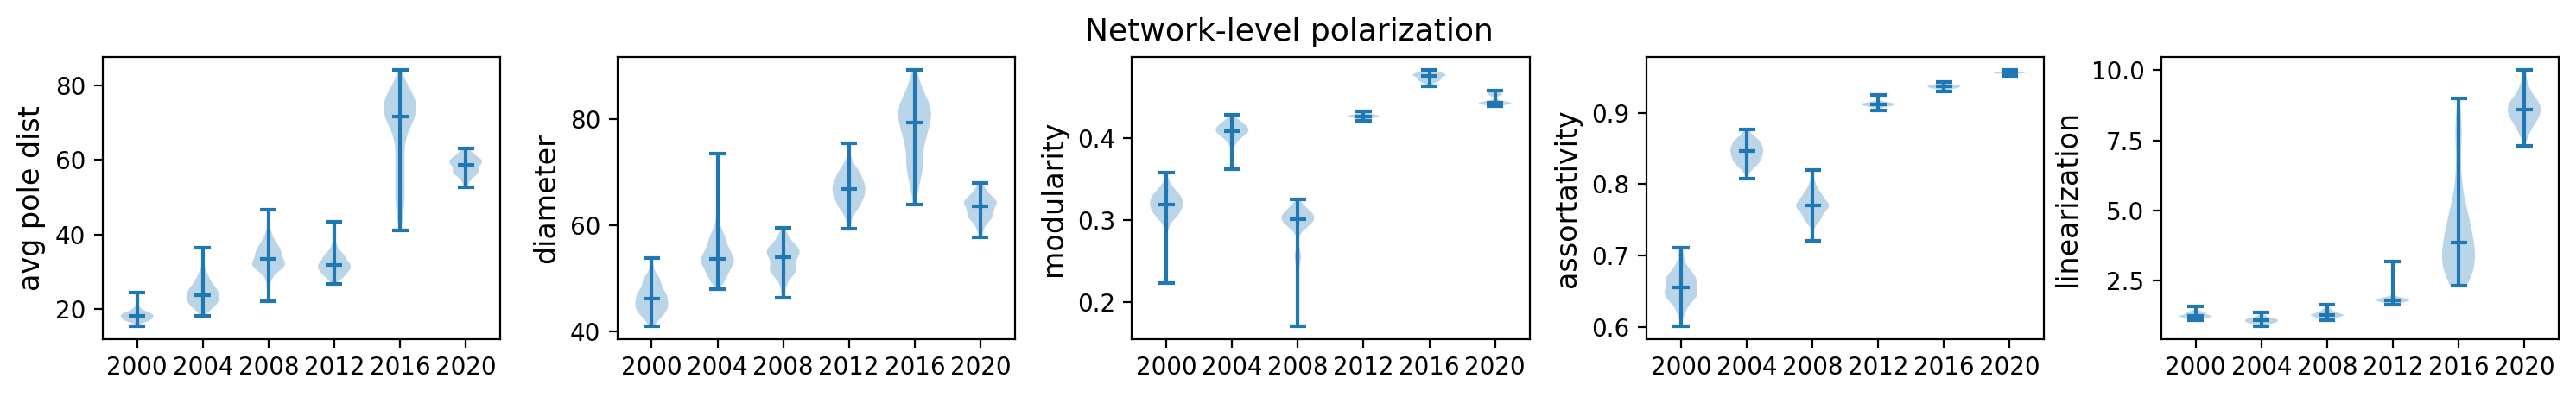

In [18]:
fig,ax = plt.subplots(ncols=5, figsize=(15,2.5))

ax[0].violinplot(list(np.mean(np.array(list(dst_ls_bstr.values())), axis=2)), showmedians=True)
ax[0].set_ylabel("avg pole dist", fontsize=12)

ax[1].violinplot(dia_ls_bstr.values(), showmedians=True)
ax[1].set_ylabel("diameter", fontsize=12)

ax[2].violinplot(mod_ls_bstr.values(), showmedians=True)
ax[2].set_ylabel("modularity", fontsize=12)

ax[3].violinplot(ast_ls_bstr.values(), showmedians=True)
ax[3].set_ylabel("assortativity", fontsize=12)

ax[4].violinplot(lin_ls_bstr.values(), showmedians=True)
ax[4].set_ylabel("linearization", fontsize=12)


for i in range(5):
    ax[i].set_xticks(range(1,7), YEARS)
plt.suptitle("Network-level polarization", fontsize=13, y=.9)
plt.tight_layout()
plt.savefig(OUTPATH + "network-level-polar-all.pdf", dpi=300, bbox_inches="tight")

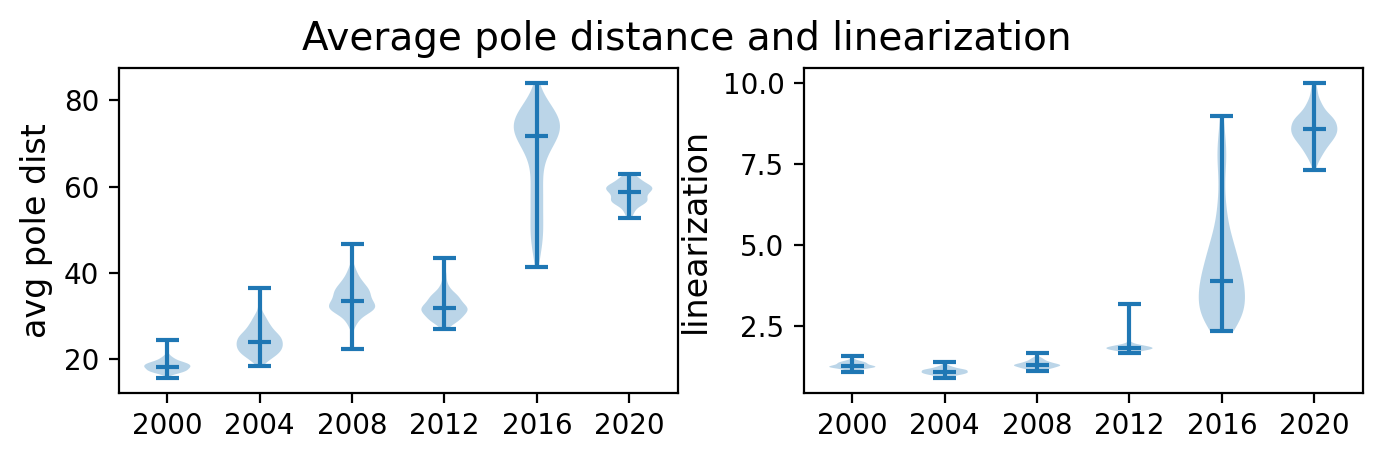

In [11]:
fig,ax = plt.subplots(ncols=2, figsize=(7,2.5))

ax[0].violinplot(list(np.mean(np.array(list(dst_ls_bstr.values())), axis=2)), showmedians=True)
ax[1].violinplot(lin_ls_bstr.values(), showmedians=True)

ax[0].set_ylabel("avg pole dist", fontsize=12)
ax[1].set_ylabel("linearization", fontsize=12)

for i in range(2):
    ax[i].set_xticks(range(1,7), YEARS)
plt.suptitle("Average pole distance and linearization ", fontsize=14, y=.9)

plt.tight_layout()
# plt.savefig(OUTPATH + "network-level-polar-dst-lin.pdf", dpi=300, bbox_inches="tight")

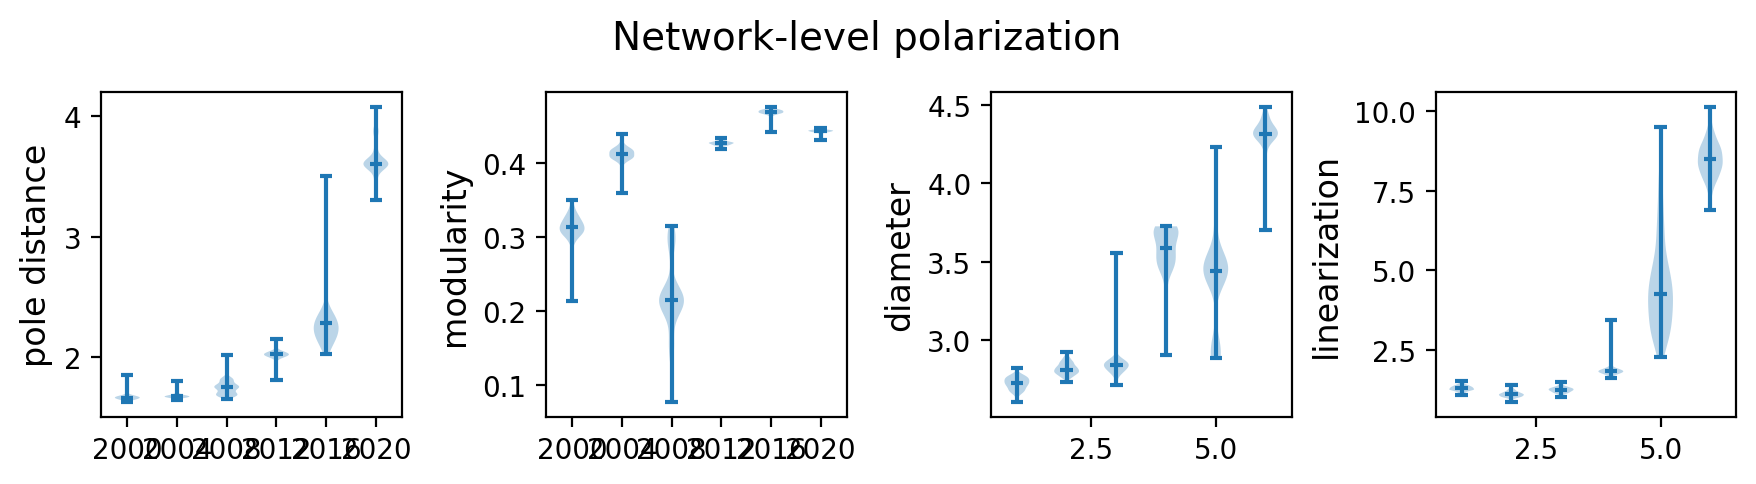

In [22]:
fig,ax = plt.subplots(ncols=4, figsize=(9,2.5))

ax[0].violinplot(list(np.mean(np.array(list(dst_ls_bstr.values())), axis=2)), showmedians=True)
ax[1].violinplot(mod_ls_bstr.values(), showmedians=True)
ax[2].violinplot(dia_ls_bstr.values(), showmedians=True)
ax[3].violinplot(lin_ls_bstr.values(), showmedians=True)

ax[0].set_ylabel("pole distance", fontsize=12)
ax[1].set_ylabel("modularity", fontsize=12)
ax[2].set_ylabel("diameter", fontsize=12)
ax[3].set_ylabel("linearization", fontsize=12)
for i in range(2):
    ax[i].set_xticks(range(1,7), YEARS)
plt.suptitle("Network-level polarization", fontsize=14, y=.95)
plt.tight_layout()
# plt.savefig(OUTPATH + "network-level-polar-new.pdf", dpi=300, bbox_inches="tight")

In [15]:
# fig,ax = plt.subplots(ncols=3, figsize=(10,2.5))

# ax[0].violinplot(mod_ls_bstr.values(), showmedians=True)
# ax[1].violinplot(dia_ls_bstr.values(), showmedians=True)
# ax[2].violinplot(lin_ls_bstr.values(), showmedians=True)
# ax[0].set_ylabel("modularity", fontsize=12)
# ax[1].set_ylabel("diameter", fontsize=12)
# ax[2].set_ylabel("linearization", fontsize=12)
# for i in range(3):
#     ax[i].set_xticks(range(1,7), YEARS)
# plt.suptitle("Network-level polarization", fontsize=14, y=.95)
# plt.tight_layout()
# plt.savefig(OUTPATH + "network-level-polar_distance1devide.pdf", dpi=300, bbox_inches="tight")

In [24]:
NODE_COLORS = {
    "spend_serv":"#6A9AB0",
    "gov_health":"#8FD14F",
    "guar_jobs":"#FCCD2A",
    "abort":"#CB80AB",
    "aid_black":"#3C3D37",
}

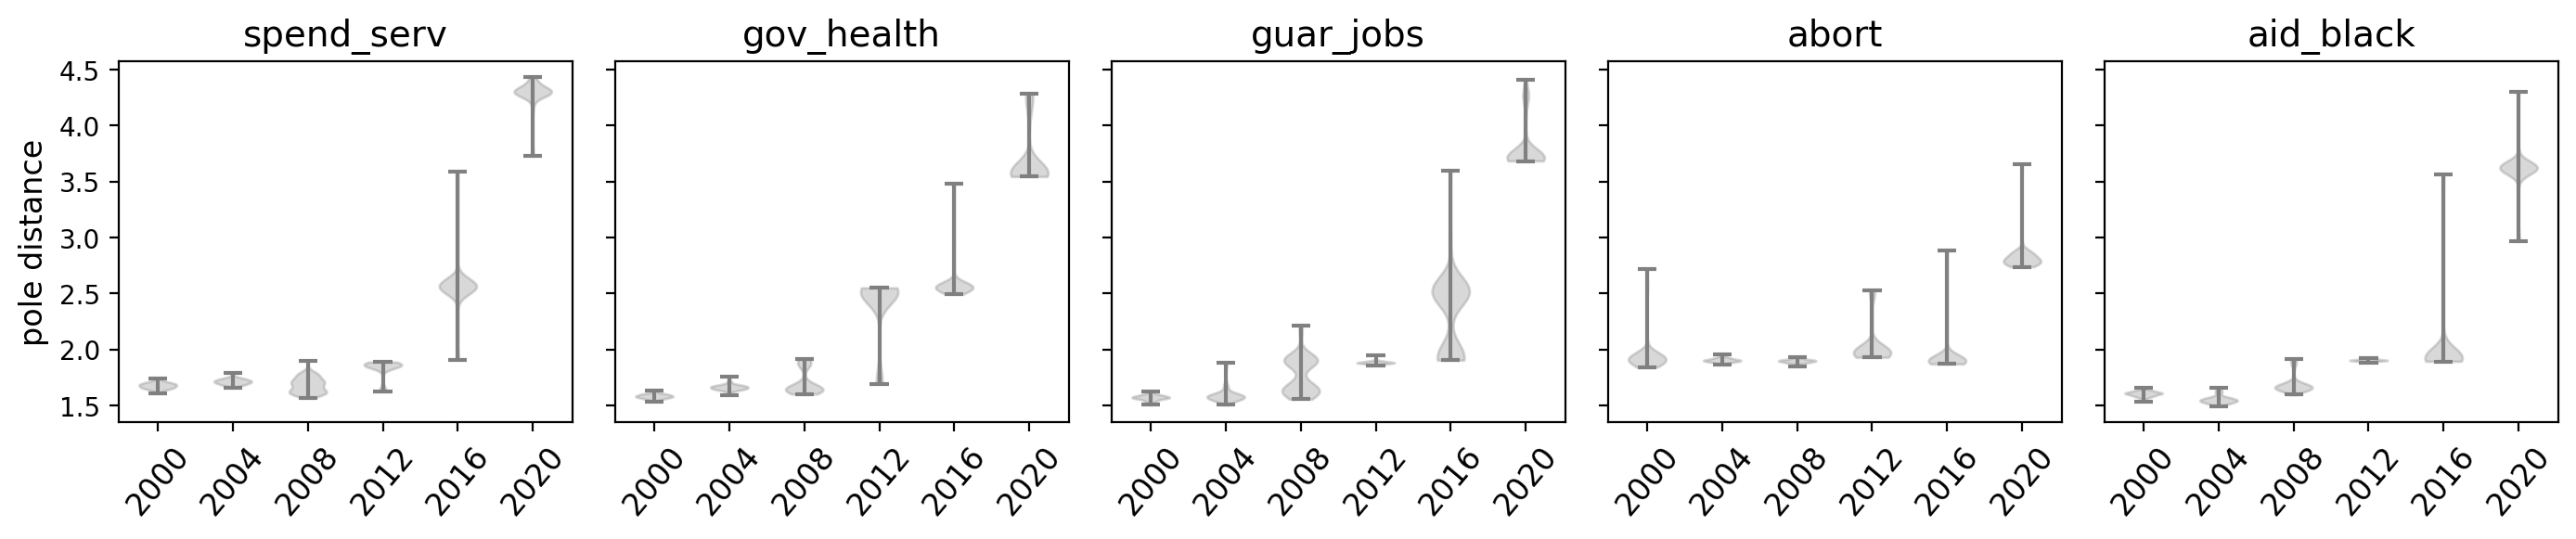

In [44]:
fig,ax = plt.subplots(figsize=(14,3), ncols=5, sharey=True)
for i,node in enumerate(NODE_COLS):
    vp = ax[i].violinplot(np.array(list(dst_ls_bstr.values()))[:,:,i].T)
    for pc in vp["bodies"]:
        pc.set_facecolor("grey")
        pc.set_edgecolor("grey")
    for elem in ("cbars","cmins","cmaxes"):
        vp[elem].set_edgecolor("grey")
    ax[i].set_xticks(range(1,len(YEARS)+1), YEARS, fontsize=12, rotation=50)
    ax[i].set_title(node, fontsize=14)
ax[0].set_ylabel("pole distance", fontsize=12)
plt.tight_layout()
plt.savefig(OUTPATH + "issue-level-pole-distance.pdf", dpi=300, bbox_inches="tight")

## Node level

In [45]:
from src.polar_measures import get_centrality_df 

centrality_df_all = pd.DataFrame()
for year in YEARS:
    print(year)
    resin = RESIN_DICT[year]
    centrality_df_year = get_centrality_df(resin)
    centrality_df_year["year"] = year 
    centrality_df_all = pd.concat([centrality_df_all, centrality_df_year])

2000
2004
2008
2012
2016
2020


In [46]:
size_df = pd.DataFrame()
size_df["node"] = list(RESIN_DICT[2020].g.nodes())
size_df["issue"] = size_df["node"].map(lambda x: x.split(":")[0])
for year,resin in RESIN_DICT.items():
    g = resin.g
    size_df[f"{year}_size"] = size_df["node"].map(lambda x: resin.node_attrs["size"][x])
    # size_df[f"{year}_size"] = size_df[f"{year}_size"]/size_df[f"{year}_size"].sum()
    size_df[f"{year}_thm"] = size_df["node"].map(lambda x: resin.node_attrs["ft_rep_net"][x])
    size_df[f"{year}_strgth"] = size_df["node"].map(lambda x: g.degree(weight="weight")[x])
    size_df[f"{year}pos_x"] = size_df["node"].map(lambda x: resin.pos_new[x][0])
    if year in [2004, 2020]:
        size_df[f"{year}pos_x"] = -size_df[f"{year}pos_x"]

size_aggr = size_df.groupby("issue").agg({f"{y}_size": lambda x: np.sum(list(x)) for y in YEARS}).reset_index()
size_aggr.rename(columns={f"{y}_size": f"{y}_size_all" for y in YEARS}, inplace=True)
size_df = size_df.merge(size_aggr, on="issue", how="left")
for year in YEARS:
    size_df[f"{year}_size"] = size_df[f"{year}_size"]/size_df[f"{year}_size_all"]
size_df.sort_values(by="node", inplace=True)
size_df

,node,issue,2000_size,2000_thm,2000_strgth,2000pos_x,2004_size,2004_thm,2004_strgth,2004pos_x,...,2020_size,2020_thm,2020_strgth,2020pos_x,2000_size_all,2004_size_all,2008_size_all,2012_size_all,2016_size_all,2020_size_all
0,abort:1.0,abort,0.122298,1.279070,0.645049,0.818239,0.132760,8.827273,0.616636,0.411194,...,0.110127,18.523148,1.032263,1.039219,1758,1047,1031,5855,4207,7900
30,abort:2.0,abort,0.298635,4.224101,0.509440,0.257757,0.317096,3.942953,0.446103,0.287269,...,0.242532,17.494595,1.472045,0.754770,1758,1047,1031,5855,4207,7900
25,abort:3.0,abort,0.150739,-1.407407,0.429790,0.202112,0.176695,0.126506,0.296062,-0.090565,...,0.138861,1.811321,0.543265,0.327429,1758,1047,1031,5855,4207,7900
19,abort:4.0,abort,0.428328,-11.503794,0.582992,-0.959503,0.373448,-9.762918,0.680090,-0.561684,...,0.508481,-22.477773,1.979098,-0.918111,1758,1047,1031,5855,4207,7900
18,aid_black:1.0,aid_black,0.056277,-25.325000,1.093236,0.389355,0.088537,-17.622951,1.267249,-0.408627,...,0.188707,-35.603107,1.924690,-1.173978,924,1073,1923,5188,3753,7403
15,aid_black:2.0,aid_black,0.043290,-15.558824,0.555018,-0.199440,0.058714,-25.615385,0.882589,-0.732669,...,0.122923,-34.799666,1.163563,-0.824896,924,1073,1923,5188,3753,7403
28,aid_black:3.0,aid_black,0.085498,-20.513514,0.678368,-0.665925,0.090401,-13.898876,0.694604,-0.880840,...,0.132379,-17.359712,0.783647,-0.389205,924,1073,1923,5188,3753,7403
24,aid_black:4.0,aid_black,0.270563,-10.090498,0.738281,-0.513448,0.256291,-5.636000,0.781600,-0.310191,...,0.214237,-1.582577,0.803425,0.129614,924,1073,1923,5188,3753,7403
11,aid_black:5.0,aid_black,0.162338,1.092857,0.703550,-0.173597,0.163094,2.345455,0.613134,0.380124,...,0.105093,14.755299,0.896952,0.572924,924,1073,1923,5188,3753,7403
4,aid_black:6.0,aid_black,0.173160,2.916667,0.561415,0.501045,0.178006,11.890909,0.752710,0.870069,...,0.091990,28.648294,1.217272,0.799181,924,1073,1923,5188,3753,7403


In [47]:
COLORMAP2 = {
    "1.0":"#921A40",
    "2.0":"#C75B7A",
    "3.0":"#D9ABAB",
    "4.0":"#F4D9D0",
    "5.0":"#C9DABF",
    "6.0":"#9CA986",
    "7.0":"#5F6F65",
}

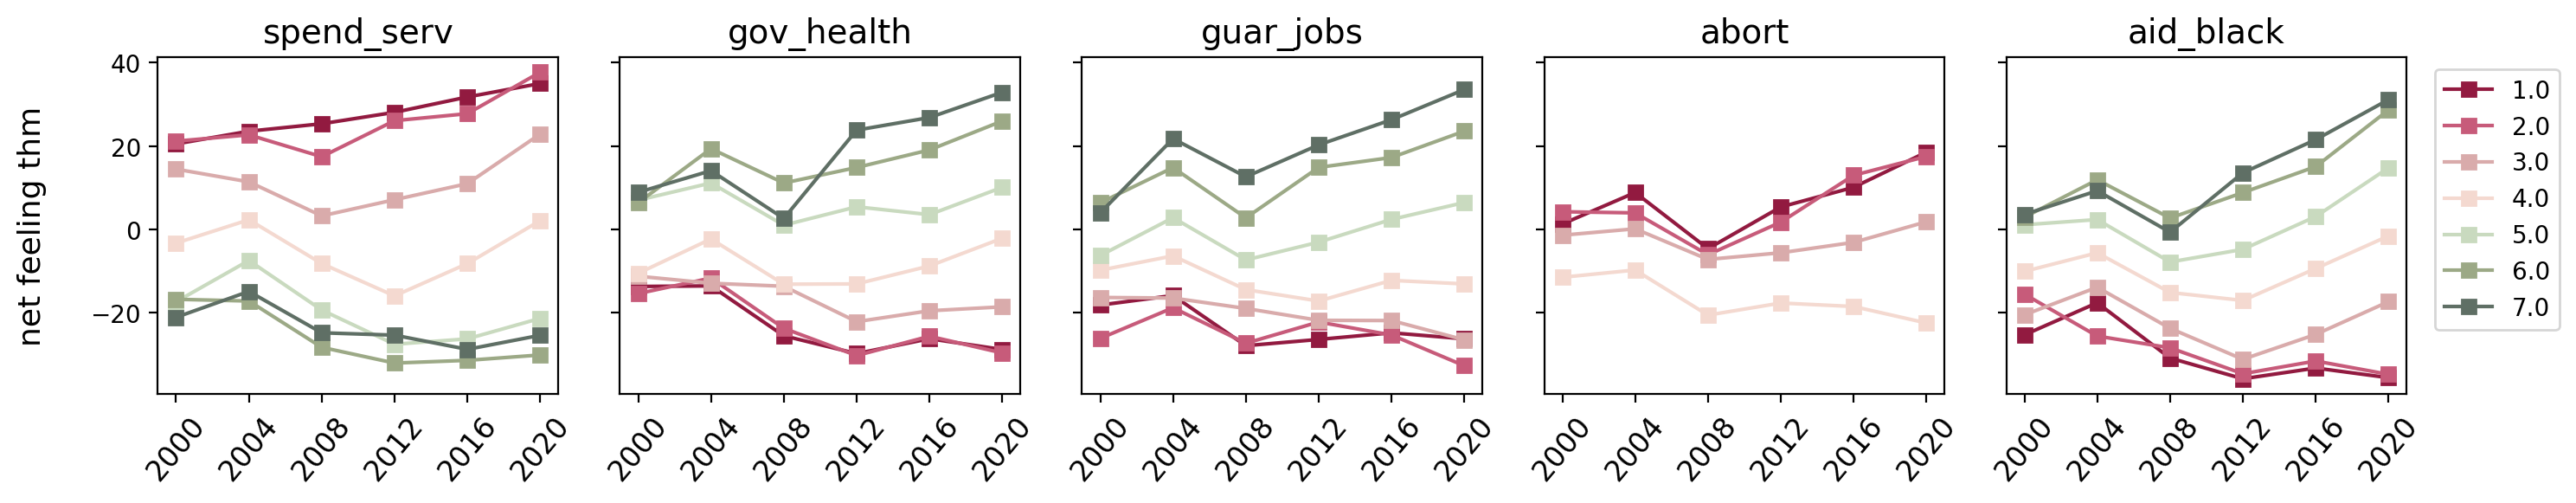

In [48]:
fig,ax = plt.subplots(figsize=(15,3), ncols=5, sharex=True, sharey=True)
# ax = [x for ls in ax for x in ls]
for i,issue in enumerate(NODE_COLS):
    issue_subdf = size_df[size_df["node"].str.contains(issue)]
    for _,row in issue_subdf.iterrows():
        level = row["node"].split(":")[1]
        ax[i].plot(range(6), row[[f"{y}_thm" for y in YEARS]].values, color=COLORMAP2[level], label=level, marker="s")
        ax[i].set_title(issue, fontsize=14)
        # ax[i].set_ylim(-45,45)
    ax[i].set_xticks(range(len(YEARS)), YEARS, fontsize=12, rotation=50)
# ax[-1].set_visible(False)
ax[-1].legend(bbox_to_anchor=(1.04,1))
# ax[0].set_ylabel("node position\n(X coordinate)", fontsize=13)
ax[0].set_ylabel("net feeling thm\n ", fontsize=13)
plt.tight_layout()
# plt.savefig(OUTPATH + "issue_temporal_net_feeling_thm.pdf", dpi=300, bbox_inches="tight")
    

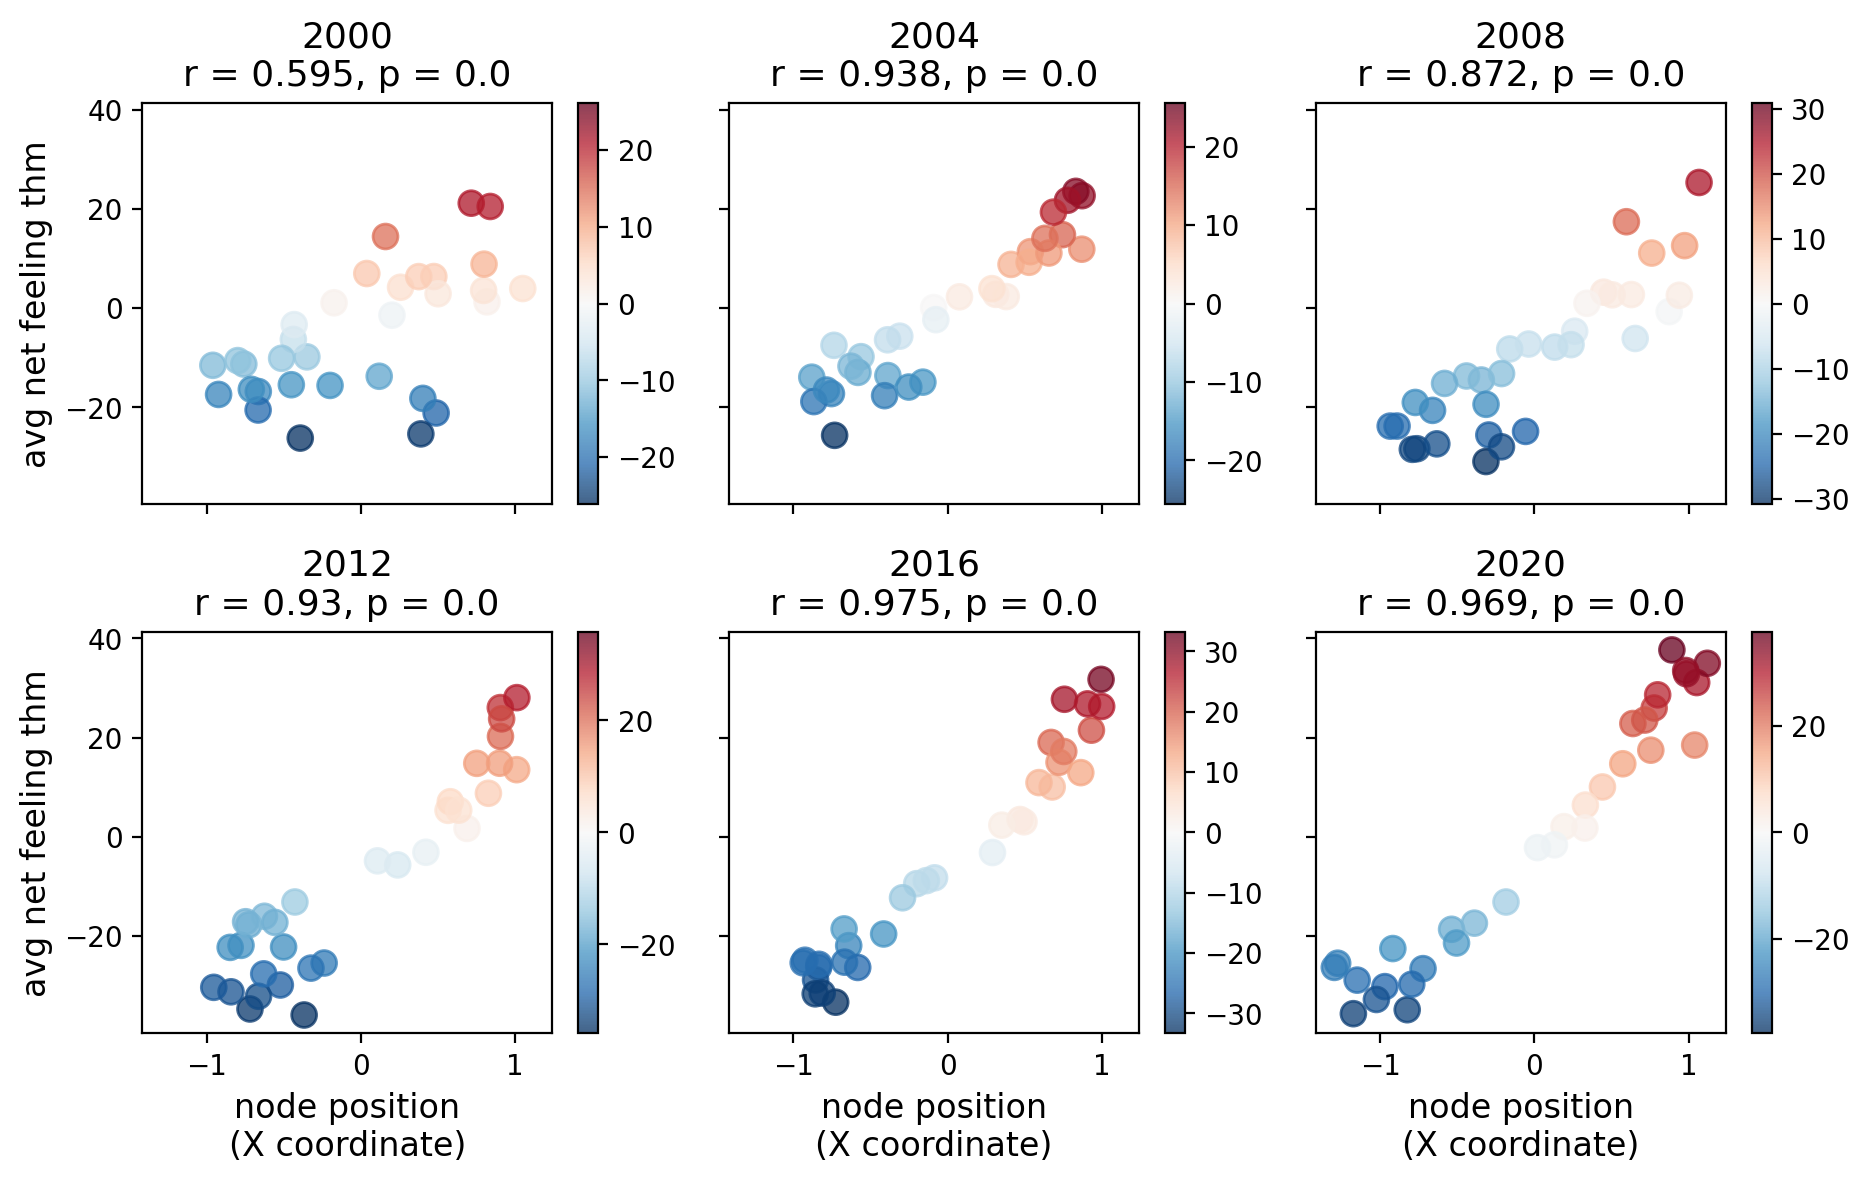

In [53]:
from scipy.stats import pearsonr 
fig,ax = plt.subplots(ncols=3, nrows=2, figsize=(9.5,6), sharey=True, sharex=True)
ax = [x for ls in ax for x in ls]
NEUTRAL_VAL = 0
color_var = "ft_rep_net"
for i, (year, resin) in enumerate(RESIN_DICT.items()):
    g = resin.g
    node_df = pd.DataFrame()
    node_df["node"] = list(g.nodes())
    node_df["strength"] = node_df["node"].map(lambda x: g.degree(weight="weight")[x])
    node_df["betweenness"] = node_df["node"].map(lambda x: nx.betweenness_centrality(g,weight="weight")[x])
    node_df["ft_rep_net"] = node_df["node"].map(lambda x: resin.node_attrs["ft_rep_net"][x])
    node_df["pos_x"] = node_df["node"].map(lambda x: resin.pos_new[x][0])
    colors = [resin.node_attrs[color_var][x] for x in resin.g.nodes()]
    color_bound = max([NEUTRAL_VAL-min(colors), max(colors)-NEUTRAL_VAL])

    if year in [2004, 2020]:
        node_df["pos_x"] = -node_df["pos_x"]
    node_df["pos_y"] = node_df["node"].map(lambda x: resin.pos_new[x][1])
    r,p = pearsonr(node_df["pos_x"], node_df["ft_rep_net"])
    sct = ax[i].scatter(node_df["pos_x"], node_df["ft_rep_net"],
                        c=node_df["ft_rep_net"], cmap="RdBu_r", s=80, alpha=.75, vmin=NEUTRAL_VAL-color_bound, vmax=NEUTRAL_VAL+color_bound)
    ax[i].set_title(f"{year}\nr = {round(r,3)}, p = {round(p,3)}", fontsize=13)
    clb = plt.colorbar(sct)
    clb.ax.tick_params(labelsize=10)
    
    if i > 2:
        ax[i].set_xlabel("node position\n(X coordinate)", fontsize=12)
    if i in [0,3]:
        ax[i].set_ylabel("avg net feeling thm", fontsize=12)
plt.tight_layout()
plt.savefig(OUTPATH + "node_ft_rep_net_pos_x.pdf", dpi=300, bbox_inches="tight")

In [26]:
for i in g.neighbors("guar_jobs:4.0"):
    print(i)

gov_health:3.0
spend_serv:4.0
aid_black:3.0
abort:4.0
aid_black:4.0
spend_serv:5.0
abort:3.0
gov_health:2.0
aid_black:2.0
gov_health:4.0


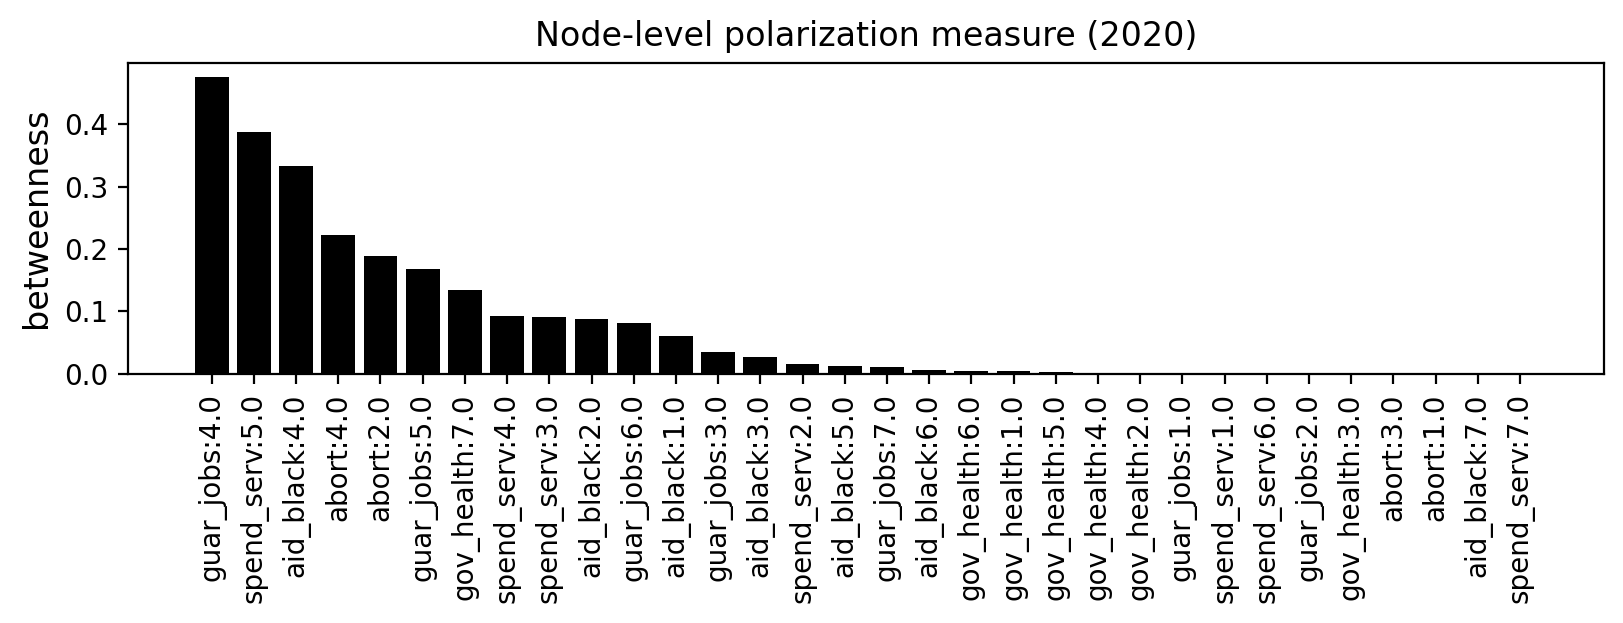

In [30]:
from matplotlib import cm

fig,ax = plt.subplots(figsize=(8,3))
year = 2020
resin = RESIN_DICT[year]
g = resin.g
node_df = pd.DataFrame()
node_df["node"] = list(g.nodes())
node_df["strength"] = node_df["node"].map(lambda x: g.degree(weight="weight")[x])
node_df["betweenness"] = node_df["node"].map(lambda x: nx.betweenness_centrality(g, weight="distance")[x])
avg_betw = np.mean(node_df["betweenness"])
# med_betw = np.median(node_df["betweenness"])
node_df["ft_rep_net"] = node_df["node"].map(lambda x: resin.node_attrs["ft_rep_net"][x])
node_df["pos_x"] = node_df["node"].map(lambda x: resin.pos_new[x][0])
node_df = node_df.sort_values(by="betweenness", ascending=False)
bar = ax.bar(
    node_df["node"],
    node_df["betweenness"],
    color="black"
    )
ax.set_xticks(range(len(node_df)), node_df["node"], rotation=90,)
plt.tight_layout()
plt.ylabel("betweenness", fontsize=12)
plt.title("Node-level polarization measure (2020)")
plt.savefig(OUTPATH + "node_bar_betweenness_2020.pdf", dpi=300, bbox_inches="tight")

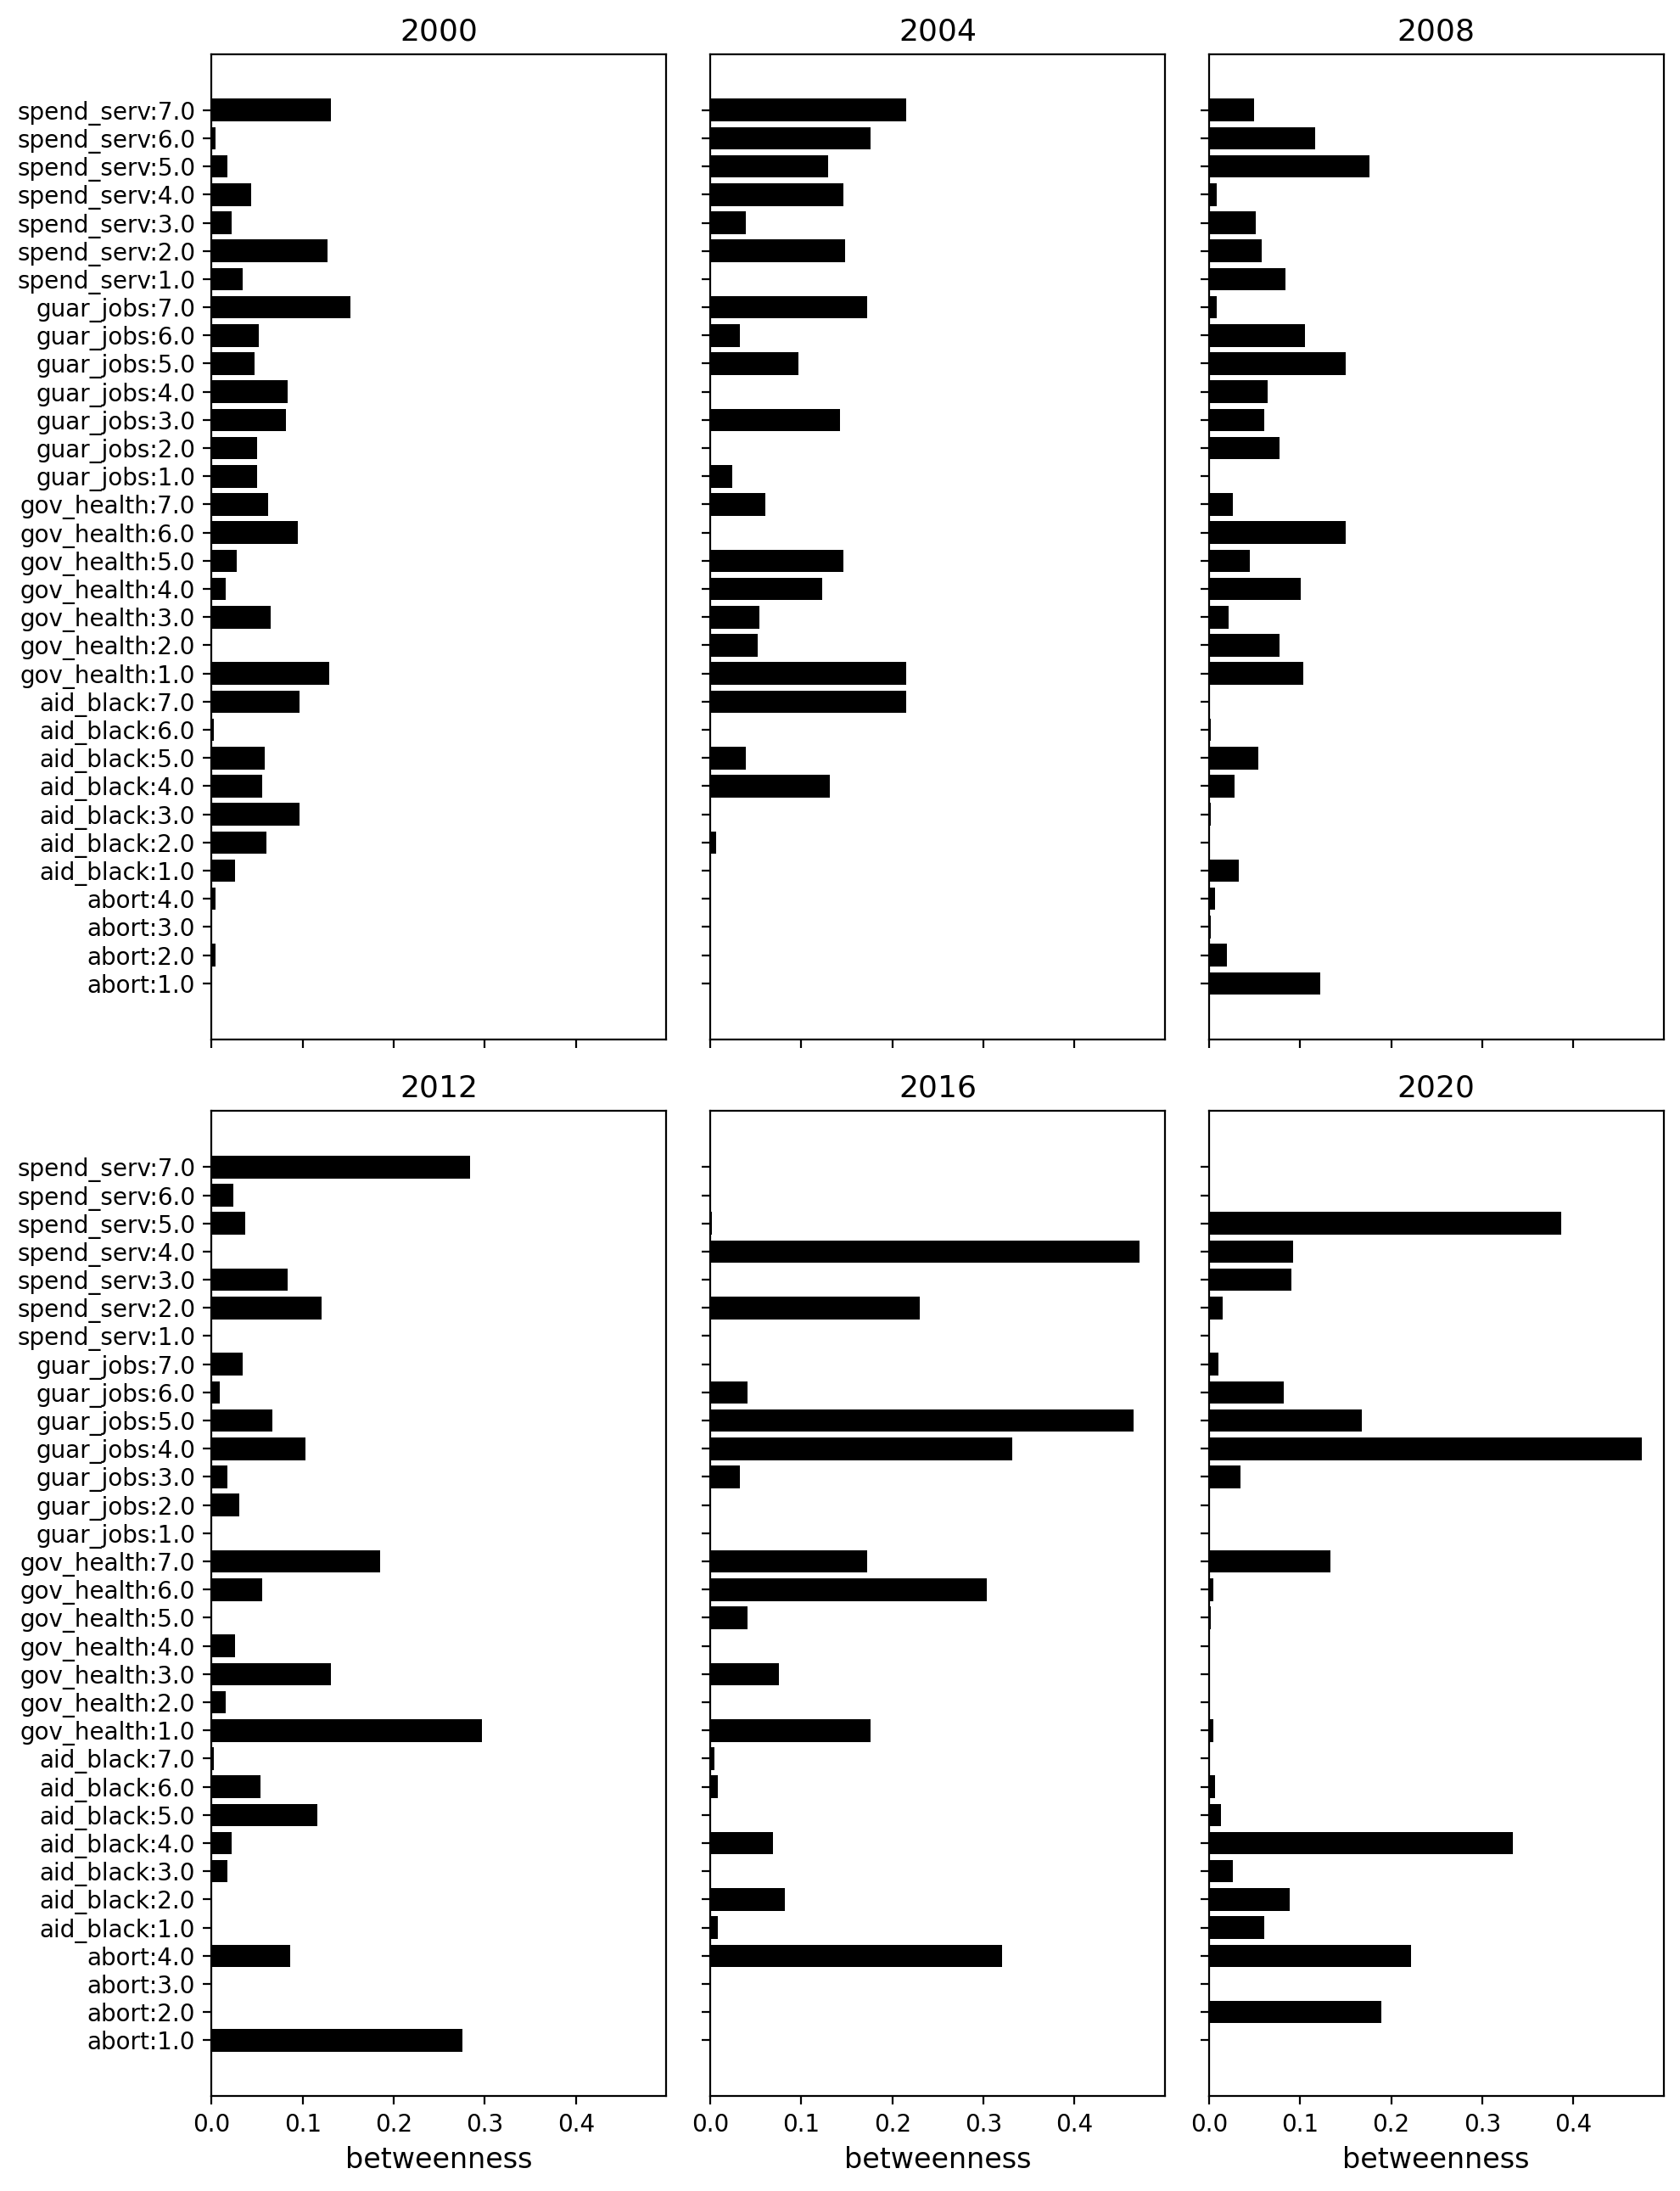

In [14]:
# from matplotlib import cm

# fig,ax = plt.subplots(ncols=3, nrows=2, figsize=(10,13), sharex=True, sharey=True)
# ax = [x for ls in ax for x in ls]
# NEUTRAL_VAL = 0
# color_var = "ft_rep_net"
# import matplotlib as mpl
# for i, (year, resin) in enumerate(RESIN_DICT.items()):
#     g = resin.g
#     node_df = pd.DataFrame()
#     node_df["node"] = list(g.nodes())
#     node_df["strength"] = node_df["node"].map(lambda x: g.degree(weight="weight")[x])
#     node_df["betweenness"] = node_df["node"].map(lambda x: nx.betweenness_centrality(g, weight="distance")[x])
#     avg_betw = np.mean(node_df["betweenness"])
#     # med_betw = np.median(node_df["betweenness"])
#     node_df["ft_rep_net"] = node_df["node"].map(lambda x: resin.node_attrs["ft_rep_net"][x])
#     node_df["pos_x"] = node_df["node"].map(lambda x: resin.pos_new[x][0])
#     # node_df = node_df.sort_values(by="ft_rep_net")
#     # node_df = node_df.sort_values(by="betweenness")
#     node_df = node_df.sort_values(by="node")
#     if year in [2004, 2020]:
#         node_df["pos_x"] = -node_df["pos_x"]
#     node_df["pos_y"] = node_df["node"].map(lambda x: resin.pos_new[x][1])
#     color_vals = node_df["ft_rep_net"]
#     colors = cm.RdBu_r((color_vals-min(color_vals))/(max(color_vals)-min(color_vals)))
#     color_bound = max([NEUTRAL_VAL-min(color_vals), max(color_vals)-NEUTRAL_VAL])
#     norm = mpl.colors.Normalize(vmin=NEUTRAL_VAL-color_bound, vmax=NEUTRAL_VAL+color_bound)
#     # ax[i].axvline(x = avg_betw, color="lightgrey", linestyle="--")
#     bar = ax[i].barh(
#         node_df["node"],
#         node_df["betweenness"],
#         # color=colors,
#         color="black"
#         )
#     ax[i].set_title(f"{year}", fontsize=13)
#     if i > 2:
#         ax[i].set_xlabel("betweenness", fontsize=12)
#     # clb = plt.colorbar(sct)
#     # clb.ax.tick_params(labelsize=10)
# plt.tight_layout()
# # plt.savefig(OUTPATH + "node_bar_betweenness_net_ft_rep_sorted.pdf", dpi=300, bbox_inches="tight")

In [44]:
# this_year = 2020 
# node_df = pd.DataFrame()
# node_df["node"] = list(RESIN_DICT[this_year].g.nodes())
# node_df["ft_rep_net"] = node_df["node"].map(lambda x: RESIN_DICT[this_year].node_attrs["ft_rep_net"][x])
# node_df = node_df.sort_values(by="ft_rep_net").reset_index().drop(columns="index").reset_index().set_index("node")
# custom_dict = node_df.to_dict()["index"]

In [45]:
# from matplotlib import cm

# fig,ax = plt.subplots(ncols=6, figsize=(15,7), sharex=True, sharey=True)
# # ax = [x for ls in ax for x in ls]
# NEUTRAL_VAL = 0
# color_var = "ft_rep_net"


# # get a custom sort of the node
# this_year = 2020 
# node_df = pd.DataFrame()
# node_df["node"] = list(RESIN_DICT[this_year].g.nodes())
# node_df["ft_rep_net"] = node_df["node"].map(lambda x: RESIN_DICT[this_year].node_attrs["ft_rep_net"][x])
# node_df = node_df.sort_values(by="ft_rep_net").reset_index().drop(columns="index").reset_index().set_index("node")
# custom_dict = node_df.to_dict()["index"]

# import matplotlib as mpl
# for i, (year, resin) in enumerate(RESIN_DICT.items()):
#     g = resin.g
#     node_df = pd.DataFrame()
#     node_df["node"] = list(g.nodes())
#     node_df["strength"] = node_df["node"].map(lambda x: g.degree(weight="weight")[x])
#     node_df["betweenness"] = node_df["node"].map(lambda x: nx.betweenness_centrality(g,weight="weight")[x])
#     node_df["ft_rep_net"] = node_df["node"].map(lambda x: resin.node_attrs["ft_rep_net"][x])
#     node_df["pos_x"] = node_df["node"].map(lambda x: resin.pos_new[x][0])
#     node_df = node_df.sort_values(by="node", key=lambda x: x.map(custom_dict))
#     if year in [2004, 2020]:
#         node_df["pos_x"] = -node_df["pos_x"]
#     node_df["pos_y"] = node_df["node"].map(lambda x: resin.pos_new[x][1])
#     color_vals = node_df["ft_rep_net"]
#     colors = cm.RdBu_r((color_vals-min(color_vals))/(max(color_vals)-min(color_vals)))
#     color_bound = max([NEUTRAL_VAL-min(color_vals), max(color_vals)-NEUTRAL_VAL])
#     norm = mpl.colors.Normalize(vmin=NEUTRAL_VAL-color_bound, vmax=NEUTRAL_VAL+color_bound)
#     bar = ax[i].barh(
#         node_df["node"],
#         node_df["betweenness"],
#         color=colors,
#         )

#     ax[i].set_title(f"{year}", fontsize=13)
#     # clb = plt.colorbar(sct)
#     # clb.ax.tick_params(labelsize=10)
# plt.tight_layout()

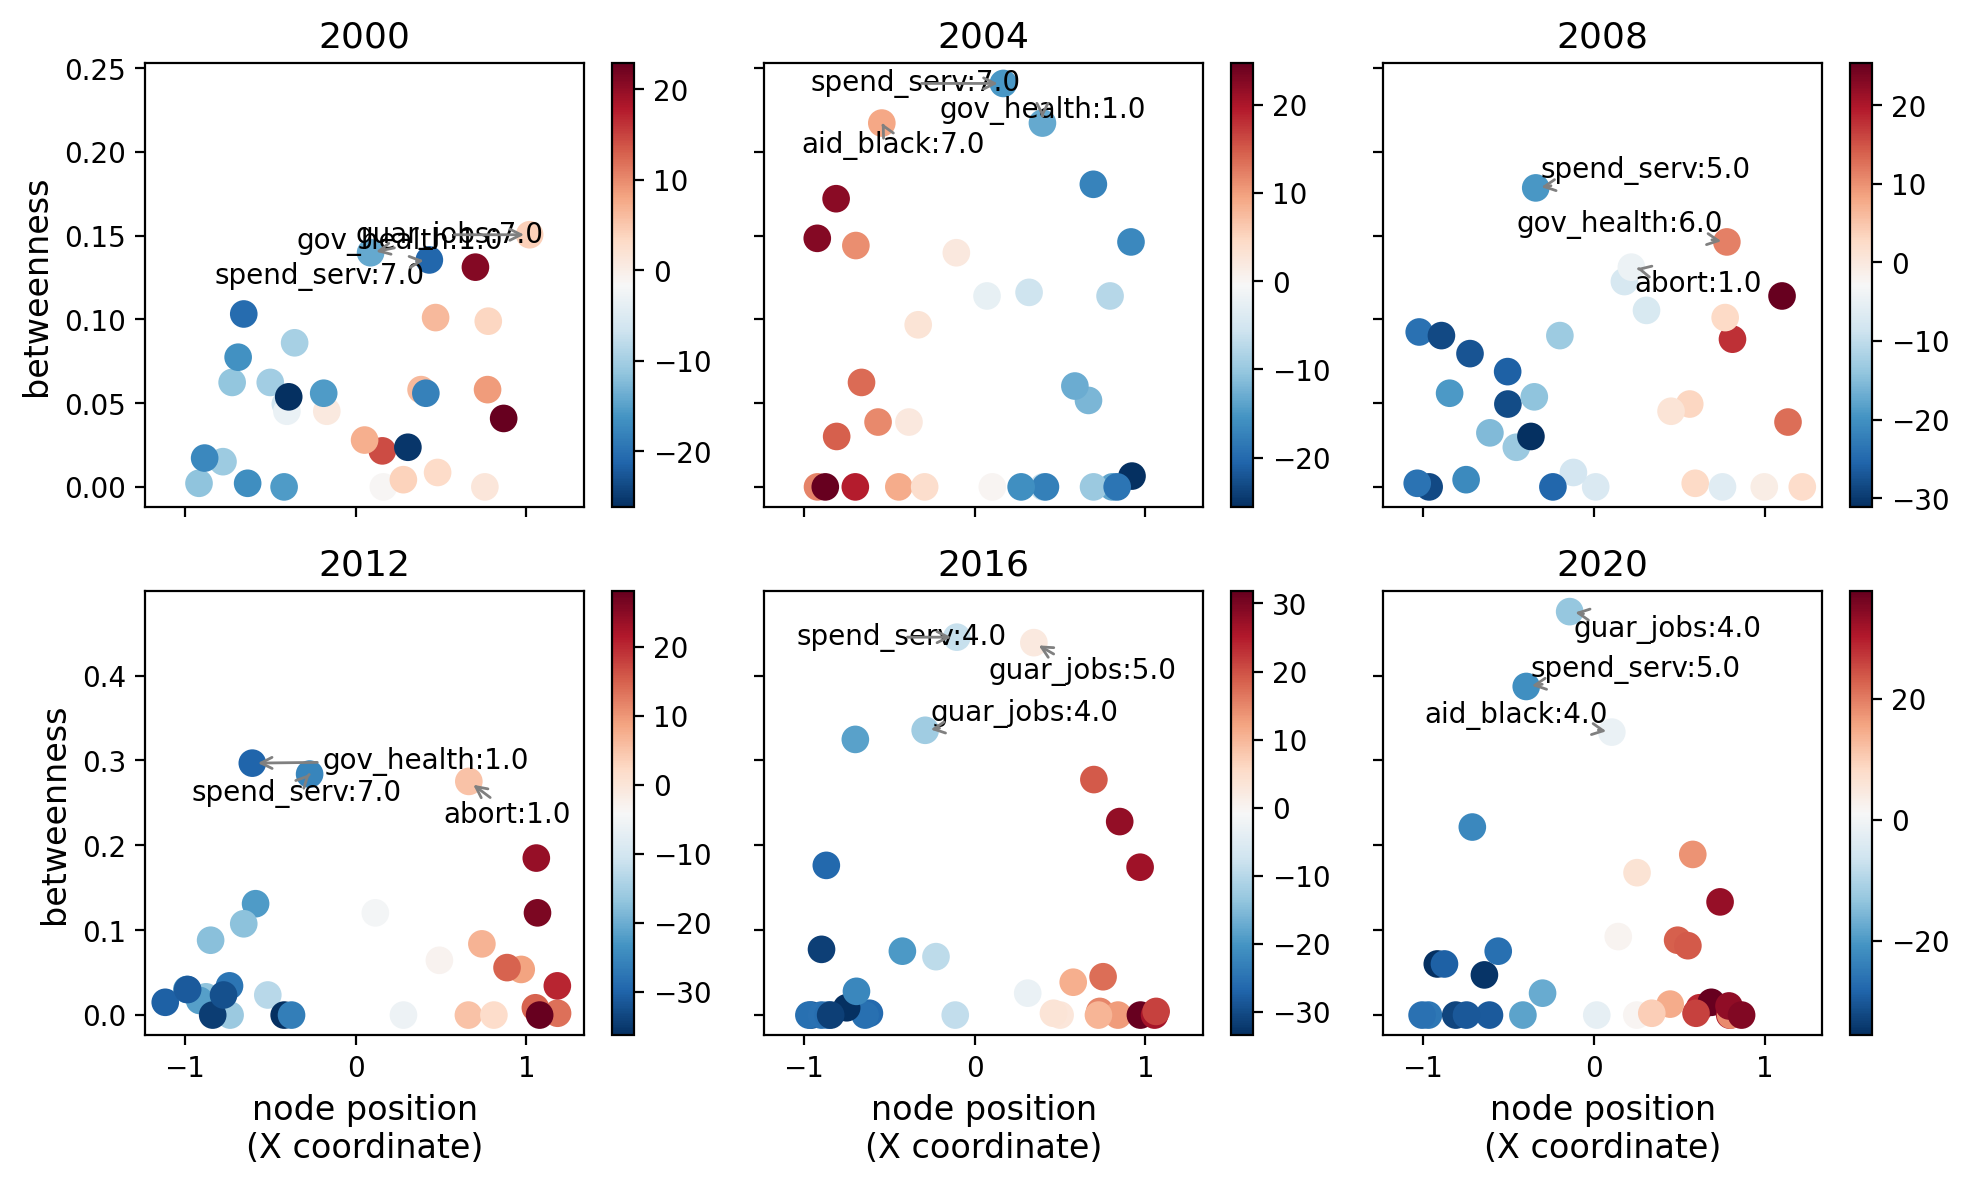

In [48]:
# fig,ax = plt.subplots(ncols=3, nrows=2, figsize=(10,6), sharey="row", sharex=True)
# ax = [x for ls in ax for x in ls]
# for i, (year, resin) in enumerate(RESIN_DICT.items()):
#     g = resin.g
#     node_df = pd.DataFrame()
#     node_df["node"] = list(g.nodes())
#     node_df["strength"] = node_df["node"].map(lambda x: g.degree(weight="weight")[x])
#     node_df["betweenness"] = node_df["node"].map(lambda x: nx.betweenness_centrality(g,weight="distance")[x])
#     node_df["ft_rep_net"] = node_df["node"].map(lambda x: resin.node_attrs["ft_rep_net"][x])
#     node_df["pos_x"] = node_df["node"].map(lambda x: resin.pos_new[x][0])
#     if year in [2004, 2020]:
#         node_df["pos_x"] = -node_df["pos_x"]
#     node_df["pos_y"] = node_df["node"].map(lambda x: resin.pos_new[x][1])
#     sct = ax[i].scatter(
#         node_df["pos_x"],
#         # node_df["ft_rep_net"],
#         node_df["betweenness"], 
#         c=node_df["ft_rep_net"], cmap="RdBu_r", s=80)
#     ax[i].set_title(f"{year}", fontsize=13)
#     node_df.sort_values(by="betweenness", ascending=False, inplace=True)
#     clb = plt.colorbar(sct)
#     clb.ax.tick_params(labelsize=10)

#     # for _,row in node_df.head(3).iterrows():
#     #     if row["betweenness"] > 0:
#     #         ax[i].annotate(row["node"], (row["pos_x"], row["betweenness"]), fontsize=10, color="grey")

#     n_labs = 3
#     x = node_df.head(n_labs)["pos_x"].tolist()
#     y = node_df.head(n_labs)["betweenness"].tolist()
#     labs = node_df.head(n_labs)["node"].tolist()
#     texts = [ax[i].text(x[n], y[n], labs[n])  for n in range(len(x))]
#     adjust_text(texts, ax=ax[i], arrowprops=dict(arrowstyle="->", color="grey"))
    
#     if i > 2:
#         ax[i].set_xlabel("node position\n(X coordinate)", fontsize=12)
#     if i in [0,3]:
#         ax[i].set_ylabel("betweenness", fontsize=12)
# plt.tight_layout()
# plt.savefig(OUTPATH + "node_pos_x_betweenness.pdf", dpi=300, bbox_inches="tight")

## Individual level: not sure now

In [7]:
# max_val = np.sum([anes_all[col].max() for col in NODE_COLS])
# anes_all["lnr_ideo_csst"] = anes_all.apply(lambda x: np.nansum([x[col] for col in NODE_COLS]/max_val), axis=1)

In [28]:
# import seaborn as sns
# fig,ax = plt.subplots(ncols=3, nrows=2, figsize=(7,5), sharey=True)
# ax = [x for ls in ax for x in ls]
# for i,year in enumerate(YEARS):
#     anes_year = anes_all[anes_all["year"]==year]
#     dem_anes_year = anes_year[anes_year["dem_rep_3"]==-1]
#     rep_anes_year = anes_year[anes_year["dem_rep_3"]==1]
#     sns.kdeplot(dem_anes_year["lnr_ideo_csst"], color="#5B99C2", ax=ax[i], fill=True, label="DEM")
#     sns.kdeplot(rep_anes_year["lnr_ideo_csst"], color="#D95F59", ax=ax[i], fill=True, label="REP")
#     # ax[i].hist(dem_anes_year["lnr_ideo_csst"], color="#5B99C2", bins=12, density=True)
#     # ax[i].hist(rep_anes_year["lnr_ideo_csst"], color="#D95F59", bins=12, density=True)
#     ax[i].set_title(year, fontsize=12)
#     # ax[i].set_xlim(0,1)
#     if i in [0,3]:
#         ax[i].set_ylabel("Density", fontsize=12)
#     if i == 4: 
#         ax[i].set_xlabel("Ideological Consistency", fontsize=12)
#     else:
#         ax[i].set_xlabel("")
# plt.tight_layout()



In [ ]:
# import matplotlib.patches as mpatches
# fig,ax = plt.subplots(figsize=(12,3))

# labels = []
# pos_diff = [-0.25, -0.15, -0.05, 0.05, 0.15, 0.25]

# def add_label(violin, label):
#     color = violin["bodies"][0].get_facecolor().flatten()
#     labels.append((mpatches.Patch(color=color), label))

# for i in range(5):
#     vp = ax.violinplot(np.array(list(dst_ls_bstr.values()))[:,:,i].T, positions=np.arange(6)+pos_diff[i])
#     c = NODE_COLORS[NODE_COLS[i]]
#     for pc in vp["bodies"]:
#         pc.set_facecolor(c)
#         pc.set_edgecolor(c)
#     for elem in ("cbars","cmins","cmaxes"):
#         vp[elem].set_edgecolor(c)
#     add_label(vp, NODE_COLS[i])